# Principal Component Analysis (PCA)
PCA is a **linear dimensionality reduction technique**. It is a versatile statistical method used for reducing high-dimensional data to its essential features, called <span style='color:rgb(28, 207, 0)'> principal components</span>. Through principal components analysis we should be able to spot much more easily trends, patterns and outliers in the data.

# Mathematical Intuition
## Problem statement
PCA is essentially a change-of-basis problem: we want to determine the right **orthogonal linear transformation** (change of basis matrix) such that the starting data samples can be analyzed at a glance. More rigorously, suppose we have $n$ data samples of $m$ features each. We know that they can be represented as $m$-dimensional vectors in a field of choice $K$ (usually $\mathbb R$). Then, we can define the $m\times n$ matrix $X$, formed by the samples as its columns. PCA consists of determining the right $m\times m$ change-of-basis matrix $P$ (assumed to be orthonormal) such that:
$$
Y = PX,\ Y\in Mat_{m\times n}(K)
$$
Matrix $Y$ then should represent the newly transformed data in a resourceful way. Ok, but how do we do that?<br>
<div class="alert alert-block alert-danger">
Since PCA varies greatly based on variance, <b>samples must be standardized</b> before proceeding: data should reflect a normal distribution with a mean of zero and a standard deviation of one.<br>
Mathematically, this also means that the covariance matrix of the samples can be written in a nicer form (see below).
</div>

## The covariance matrix
We can take into account the **covariance matrix** $C_Y = \frac{1}{n-1}YY^T$ (formula justified by standardization) of the transformed data samples matrix $Y$. In particular, we impose the following requirements on the matrix $C_Y$:
- **Covariance** of $Y$'s variables **should be minimized**. Equivalently, $C_Y$'s off-diagonal entries should be minimized. This is a fundamental assumption of the PCA technique, its working principle.
- Since large variance values correspond to potentially interesting samples' dynamics, **variance** of $Y$'s variables **should be maximized**. Equivalently, $C_Y$'s diagonal entries should be maximized.

Since the minimum of the covariance entries of $C_Y$ is $0$, we can conclude that $C_Y$ should be **diagonal**.<br>
In other words, these requirements represent what makes PCA a very useful dimensionality reduction technique for visualizing and processing datasets: it renders the initial samples in a vector space where variance is retained as much as possible, letting data being as spread out as possible around their mean value, while removing as much covariance as possible, thus spreading out **data clusters**. Therefore, we can see PCA as a clustering analysis tool, too!
## Eigendecomposition
Without going into the details, we can write the following formula for it:
$$
C_Y = \frac{1}{n-1}D
$$
With $D$ being the eigenvalues' diagonal matrix obtained from the **eigendecomposition** of the matrix $XX^T$, along with the eigenvectors' matrix $E = P^T$:
$$
XX^T = EDE^T \equiv (P^T)D(P^T)^T = P^TDP
$$
Thus, it is clear now that **PCA analysis is mathematically an eigenvalue problem**:
- The rows of the matrix $P$ are the eigenvectors of the non-normalized covariance matrix $XX^T$ and are called **principal components**.
- The eigenvalues correspond to the variances in the new vector space: the more the variance (or the eigenvalue), the more important the associated principal component (or the associated eigenvector). Eigenvalues are sometimes called **explained variance**.

<div class="alert-success">
Remember that <b>the trace of a matrix is equal to the sum of its eigenvalues</b>. Therefore, all the variance of the original data is completely accounted for by the principal components, just distributed differently among them. The first few principal components usually capture most of it, while the later ones capture progressively less. This is why it's the <b>explained variance ratios</b> that are analyzed instead of just the original eigenvalues. See the analysis below for more details. 
</div>

Since $P$ is now determined, computing the matrix $Y$ is pretty simple now. The reduction of dimensionality is achieved by choosing how many dimensions to take from the data matrix $Y$.


# Applications and Examples
PCA proves useful in many contexts, like:
- cluster analysis
- principal component regression
- noisy data analysis 

and even in some unexpected ones, such as:
- image compression
- blind source separation

These are really interesting applications of principal component analysis, so I recommend checking them out.<br>

Let's see a simple example with the famous **Fisher's Iris data set**, characterized by the following properties:<br>
<!-- Use HTML since defining the table with markdown doesn't render it centered.-->
<table style="margin-left: auto; margin-right: auto;">
    <tr>
        <th>Classes</th>
        <td>3</td>
    </tr>
    <tr>
      <th>Samples per class</th>
      <td>50</td>
    </tr>
    <tr>
      <th>Samples total</th>
      <td>150</td>
    </tr>
    <tr>
      <th>Dimensionality</th>
      <td>4</td>
    </tr>
    <tr>
      <th>Features</th>
      <td>real, positive</td>
    </tr>
</table>

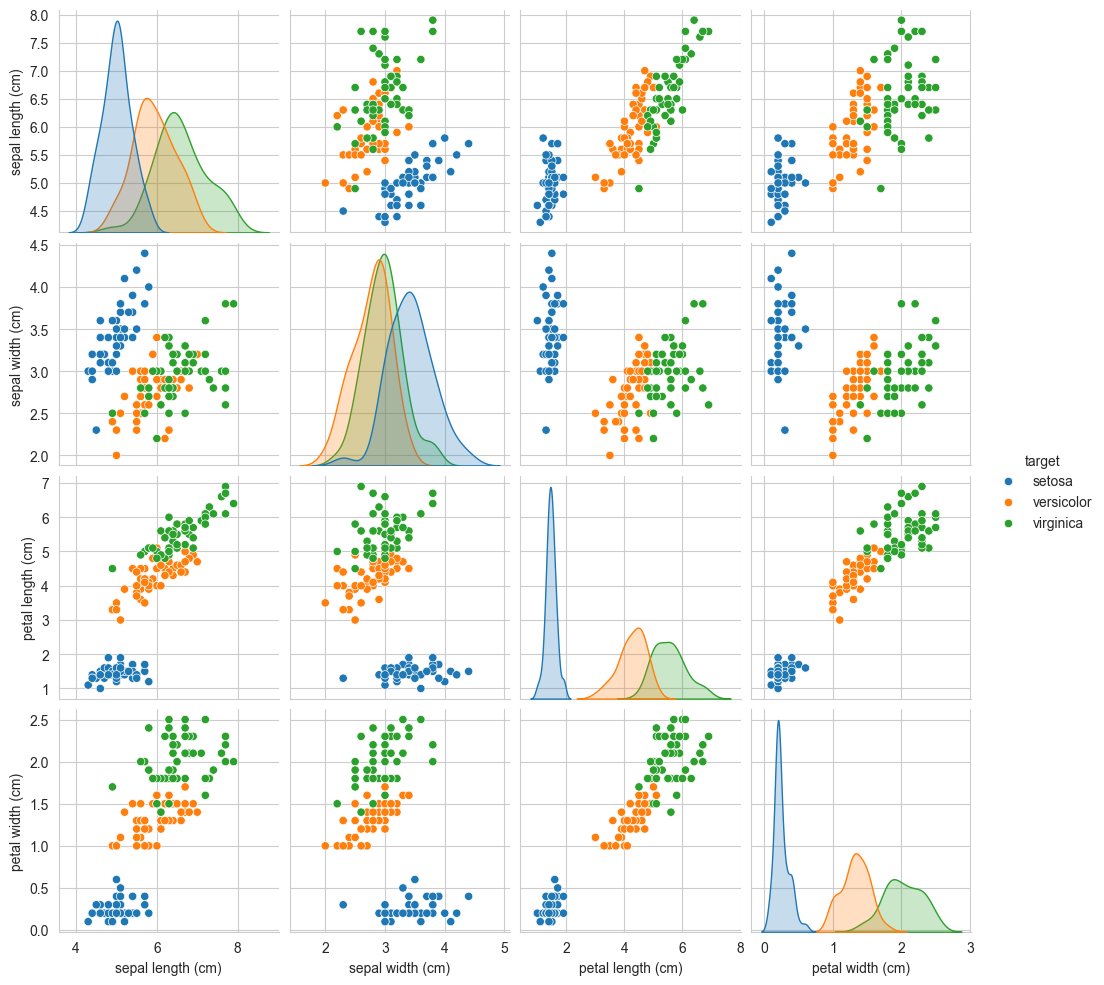

In [28]:
%matplotlib inline
import seaborn as sns   # For data visualization
from sklearn.datasets import load_iris  # For dataset
from sklearn.preprocessing import StandardScaler        # For data standardization

# Load dataset
data = load_iris(as_frame=True)

# Standardize data
sc = StandardScaler()
data.data = sc.fit_transform(data.data)

# Rename classes using the iris target names
data.frame["target"] = data.target_names[data.target]

# Plot pairwise features' relationships + 
# marginal distribution of each feature
sns.set_style("whitegrid")
_ = sns.pairplot(data.frame, hue="target")

The Setosa type is clearly distinguishable based on its short and narrow petals. However, based on sepal width and length it is pretty difficult to differentiate the three classes.<br>
Let's now apply PCA and experiment with different numbers of dimensions. 

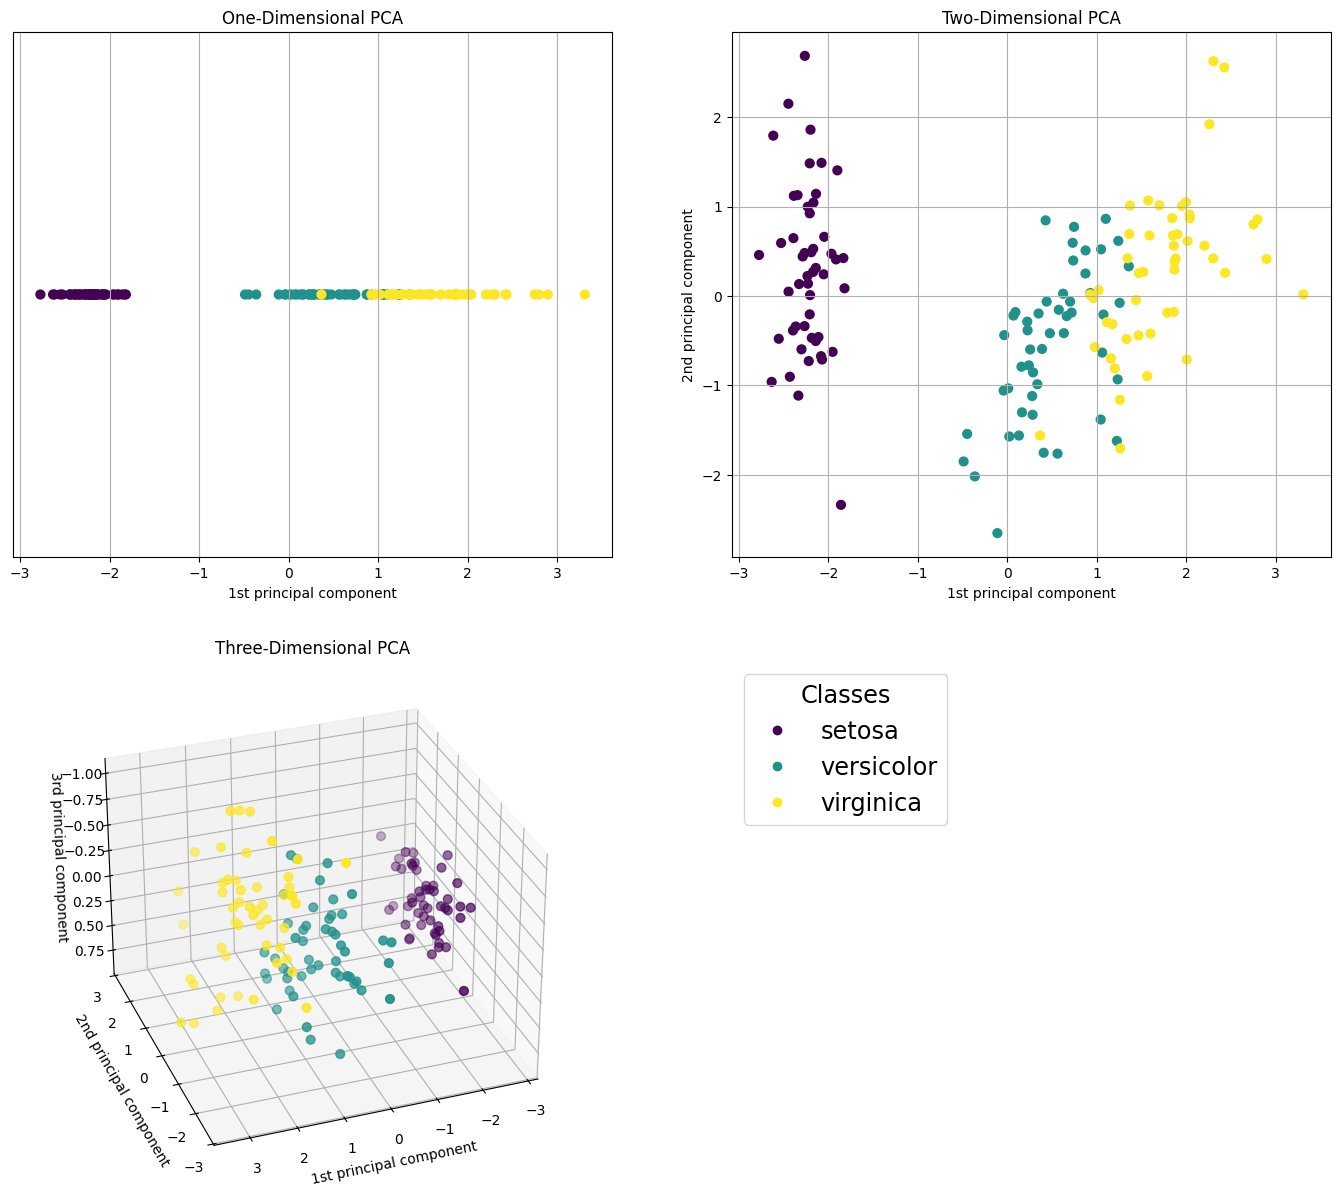

In [23]:
import numpy as np
import matplotlib.pyplot as plt                         # For easy plotting
import matplotlib.gridspec as gridspec                  # For easier disposition of subplots
from sklearn.decomposition import PCA                   # For PCA


# Apply PCA
pca = PCA()
proj = pca.fit_transform(data.data)
fig = plt.figure(figsize=(17, 15))

# Instantiate a GridSpec object representing a 2x2 grid of subplots
grid = gridspec.GridSpec(2, 2)

# 1D PCA
ax1 = fig.add_subplot(grid[0, 0])
ax1.scatter(proj[:, 0], np.zeros_like(proj[:, 0]), c=data.target, s=40)
ax1.grid()
ax1.set_title("One-Dimensional PCA")
ax1.set_yticks([])
ax1.set_xlabel("1st principal component")

# 2D PCA
ax2 = fig.add_subplot(grid[0, 1])
ax2.scatter(proj[:, 0], proj[:, 1], c=data.target, s=40)
ax2.grid()
ax2.set_title("Two-Dimensional PCA")
ax2.set_xlabel("1st principal component")
ax2.set_ylabel("2nd principal component")

# 3D PCA
ax3 = fig.add_subplot(grid[1, 0], projection="3d", elev=-150, azim=110)
plot = ax3.scatter(proj[:, 0], proj[:, 1], proj[:, 2], c=data.target, s=40)
ax3.set_title("Three-Dimensional PCA")
ax3.set_xlabel("1st principal component")
ax3.set_ylabel("2nd principal component")
ax3.set_zlabel("3rd principal component")

## Legend
legend = fig.add_subplot(grid[1, 1])
legend.axis('off')  # Turn off the axes
legend.legend(
        plot.legend_elements()[0],
        data.target_names.tolist(),
        loc="upper left",
        #bbox_to_anchor=(0.5, 0.5, 0.14, 0.),
        title="Classes",
        title_fontsize="xx-large",
        fontsize="xx-large",
)

plt.show()

Just by following the first eigenvector we could easily distinguish most of the samples: while there might be some overlap between the Versicolor and Virginica samples, clusters are more distinguishable now.<br>
Now, let's generate a pairplot of the PCA-transformed data.

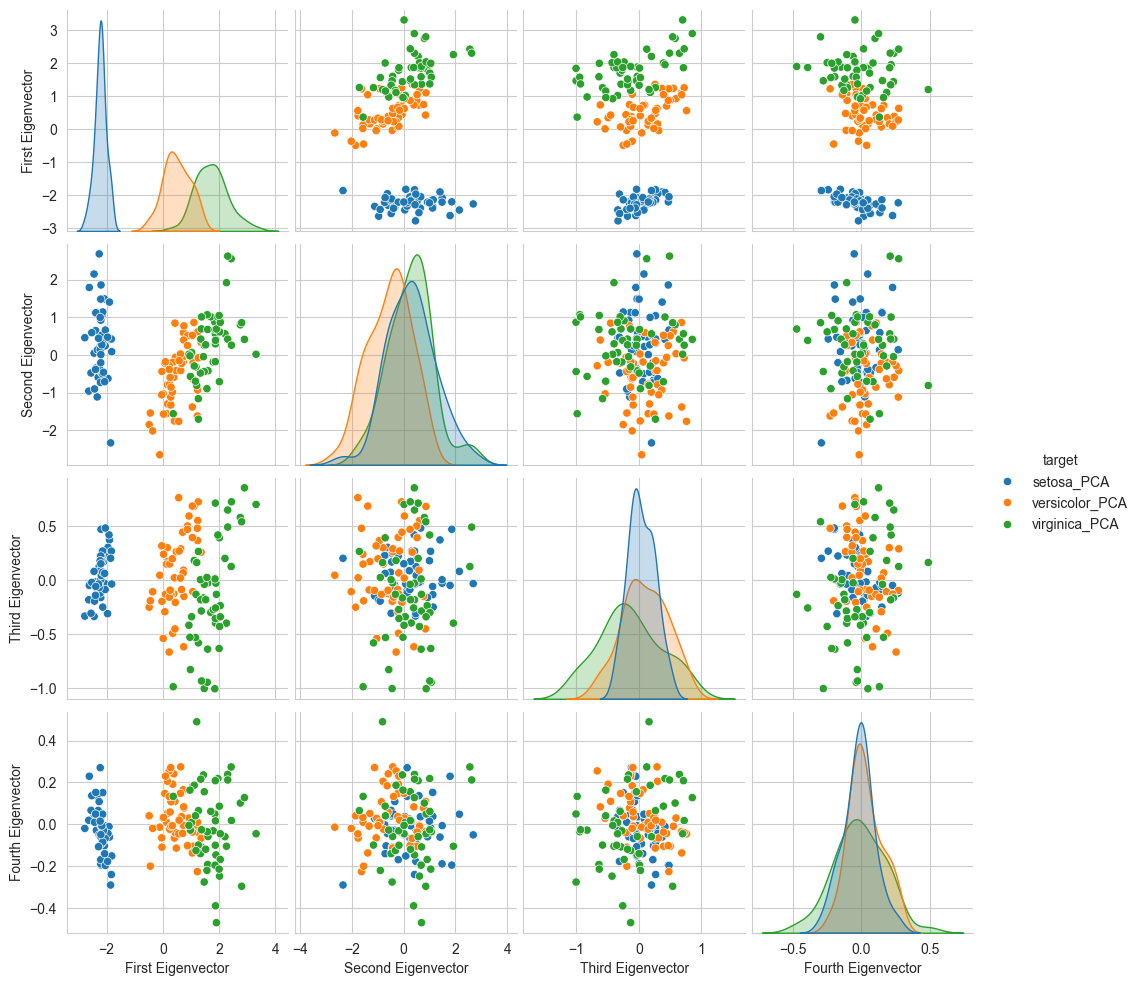

In [26]:
import pandas as pd

# Convert to panda's DataFrame
# (Create a new variable `proj_plot` instead of just re-using `proj` to avoid having to recompile everything from start)
proj_plot = pd.DataFrame(
    proj, columns=["First Eigenvector", "Second Eigenvector", "Third Eigenvector", "Fourth Eigenvector"]
)

# Add "target" column to `proj_plot` but with different target names 
# (same as `data` but with "_PCA" postfix)
proj_plot = pd.concat(
    [
        proj_plot,
        data.frame["target"].str.cat(pd.Series(["_PCA"] * 150), sep='') # Add postfix to the "target" column for `proj_plot`
    ],
    axis=1  # Append a column
)

# Generate pairplot
sns.set_style("whitegrid")
_ = sns.pairplot(proj_plot, hue="target")

Notice how the first principal component discerns data way better than all the other ones. Mathematically, the relevance of the different eigenvectors can be analyzed through the explained variance (a.k.a. the eigenvalues). `sklearn` allows us to analyze it through two `PCA`'s class attributes:
- `explained_variance_`: a `ndarray` containing the eigenvalues of the selected components. It tells exactly how much of the total variance in the original dataset is attributed to each principal component.
- `explained_variance_ratio_`: a `ndarray` with the percentage of variance "explained by" each of the selected principal components. In other words, it is equal to the following `ndarray`: `explained_variance_ / 100`. In this case all components were stored, so the sum of the rations must be equal to $1.0$.

Let's see how they can be used to analyze the above plots.

Explained Variance
[2.93808505 0.9201649  0.14774182 0.02085386]

Explained Variance Ratio
[0.72962445 0.22850762 0.03668922 0.00517871]



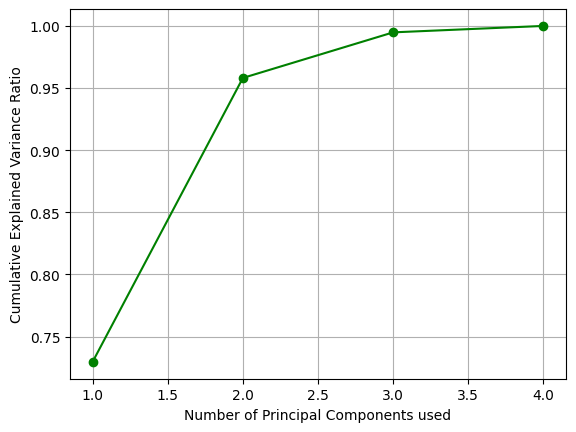

In [20]:
print("Explained Variance")
print(pca.explained_variance_)
print()

print("Explained Variance Ratio")
print(pca.explained_variance_ratio_)
print()

plt.plot(
    [1, 2, 3, 4],
    np.cumsum(pca.explained_variance_ratio_),
    marker='o',
    c='g'
)
plt.xlabel("Number of Principal Components used")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.grid()
plt.show()


The first eigenvalue equals to about $2.93$, making it around $73\%$ of all explained variance. This justifies the relevance of the first principal component, which emphasizes the most how much data is "spread-out". The second one still might help, but the third and fourth ones might not be really helpful.

# Resources
- The relevant [Wikipedia page](https://en.wikipedia.org/wiki/Principal_component_analysis#Relation_with_other_methods).
- [IBM page](https://www.ibm.com/think/topics/principal-component-analysis) on PCA.
- [Mark Richardson's lecture notes](https://people.duke.edu/~hpgavin/SystemID/References/Richardson-PCA-2009.pdf) on PCA.
- [`sklearn`'s example](https://scikit-learn.org/stable/auto_examples/decomposition/plot_pca_iris.html#sphx-glr-auto-examples-decomposition-plot-pca-iris-py) on PCA.
- [Nice introductive video](https://www.youtube.com/watch?v=FD4DeN81ODY) where PCA is analyzed graphically and used to analyze the 2021 World Happiness Report.
- [Interactive website](https://setosa.io/ev/principal-component-analysis/) where PCA is briefly introduced and used to analyze british average food consumption.
- [Nature's paper](https://doi.org/10.1038/s43586-022-00184-w) on the basics of PCA.